
# LAB 05
#### Saksham Bhujel
#### ACE080BCT063

## TASK 1

In [1]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### {DATASET = assignment-data.csv}

# 1. Data Preparation

In [3]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [4]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


### Train-Test Split

In [5]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Data Visualization Function

In [6]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

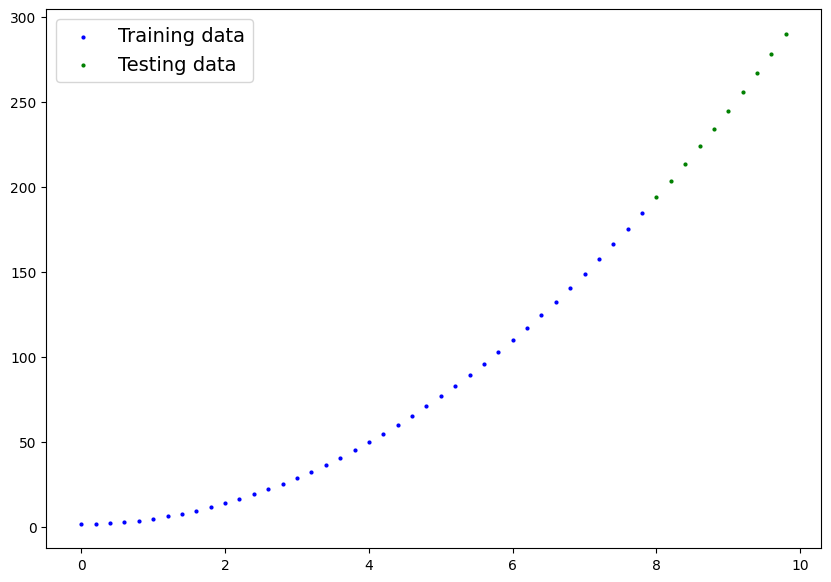

In [7]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation: These are learnable parameters which are initialized randomly.

They are updated during training using gradient descent.

In [8]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [9]:
model_0 = LinearRegressionNN()

In [10]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[1.6582],
        [1.7242],
        [1.7902],
        [1.8562],
        [1.9221]])

In [11]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[1.6582],
        [1.7242],
        [1.7902],
        [1.8562],
        [1.9221],
        [1.9881],
        [2.0541],
        [2.1201],
        [2.1861],
        [2.2521]])


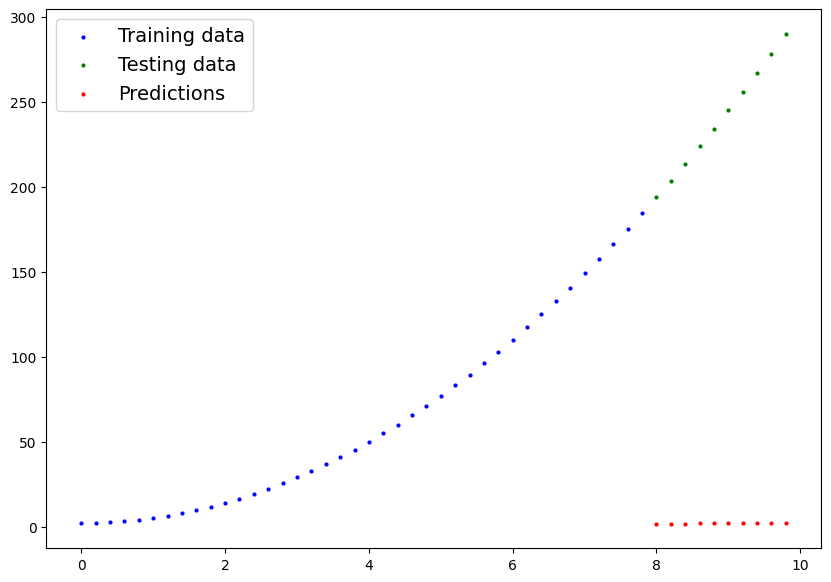

In [12]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [13]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [14]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 500

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 63.31455612182617 | MAE Test Loss: 238.30776977539062 
Epoch: 10 | MAE Train Loss: 61.69356155395508 | MAE Test Loss: 234.7367706298828 
Epoch: 20 | MAE Train Loss: 60.07255935668945 | MAE Test Loss: 231.165771484375 
Epoch: 30 | MAE Train Loss: 58.45155715942383 | MAE Test Loss: 227.5947723388672 
Epoch: 40 | MAE Train Loss: 56.83055877685547 | MAE Test Loss: 224.0237274169922 
Epoch: 50 | MAE Train Loss: 55.20955276489258 | MAE Test Loss: 220.45272827148438 
Epoch: 60 | MAE Train Loss: 53.58855438232422 | MAE Test Loss: 216.88174438476562 
Epoch: 70 | MAE Train Loss: 51.967552185058594 | MAE Test Loss: 213.3107452392578 
Epoch: 80 | MAE Train Loss: 50.34654998779297 | MAE Test Loss: 209.73974609375 
Epoch: 90 | MAE Train Loss: 48.72555160522461 | MAE Test Loss: 206.1687469482422 
Epoch: 100 | MAE Train Loss: 47.104549407958984 | MAE Test Loss: 202.5977325439453 
Epoch: 110 | MAE Train Loss: 45.483551025390625 | MAE Test Loss: 199.0267333984375 
Epoch: 120 |

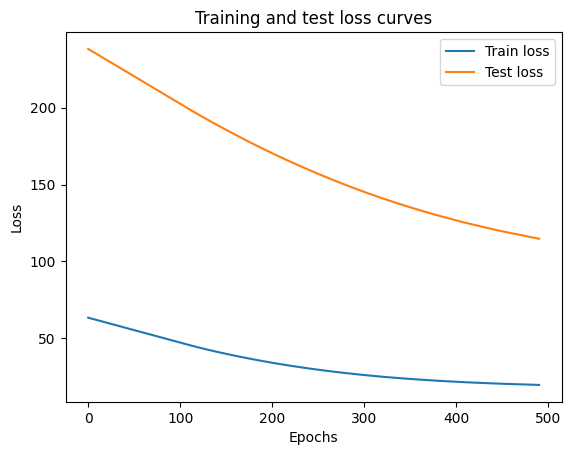

In [15]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

The curves shows training vs testing error which help to verify machine learning.

Output:

The decreasing curve shows that the model is learning.


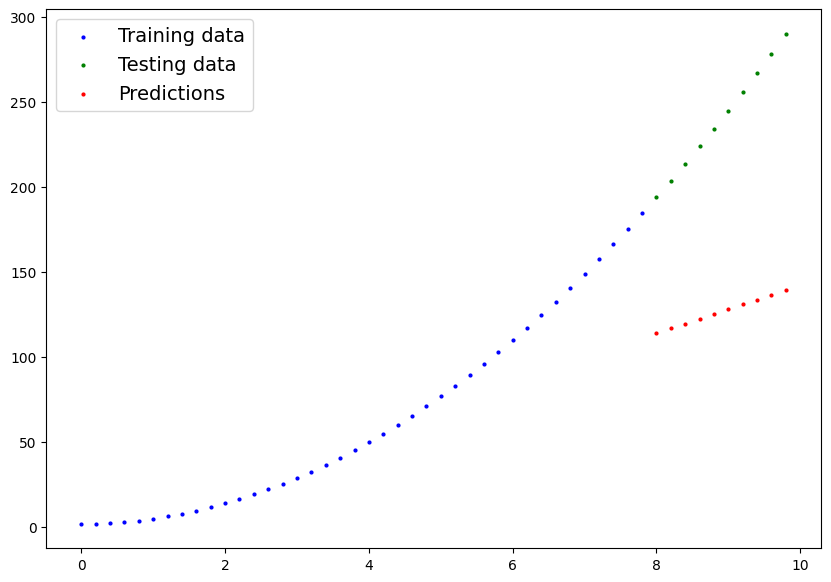

In [16]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

The Red points (predictions) align closely with actual data Indicates successful learning of quadratic relationship

### {DATASET = linear-regression-data1.csv.csv}

In [17]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [18]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### 1. Data Preparation

In [19]:
import pandas as pd
import torch

df = pd.read_csv(r'linear-regression-data1.csv')
df.head(6)

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


In [20]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


Here, Shape of X and y confirms correct tensor conversion

### Train-Test Split

In [21]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Data Visualization Function

In [22]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

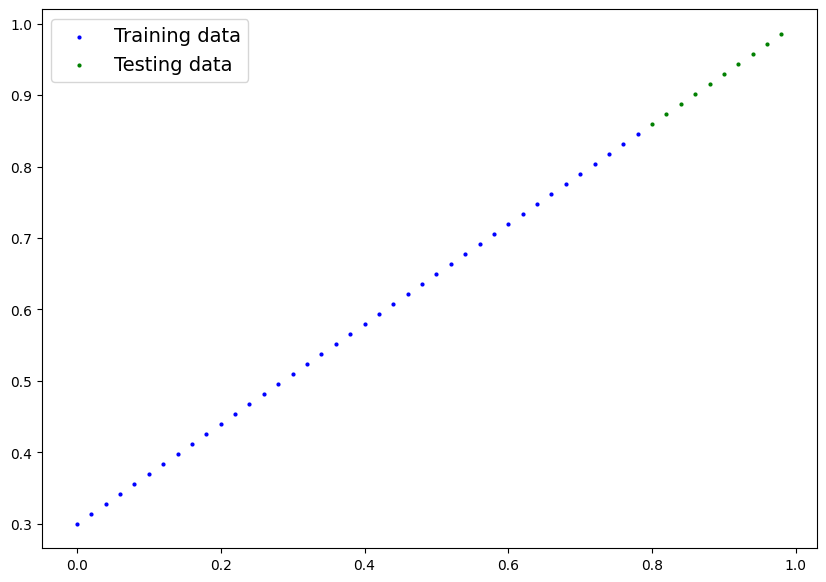

In [23]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function: Plots training data (blue), test data (green).

Output: Scatter plot showing dataset distribution Helps visually understand pattern (straight line)

### Algorithm Selection

We define a linear regression model: y = wx + b

This model is suitable because the dataset shows a straight-line relationship between input and output variables.

In [24]:
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [25]:
model_0 = LinearRegressionNN()

In [26]:


# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028]])

In [27]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028],
        [1.5181],
        [1.5334],
        [1.5487],
        [1.5640],
        [1.5793]])


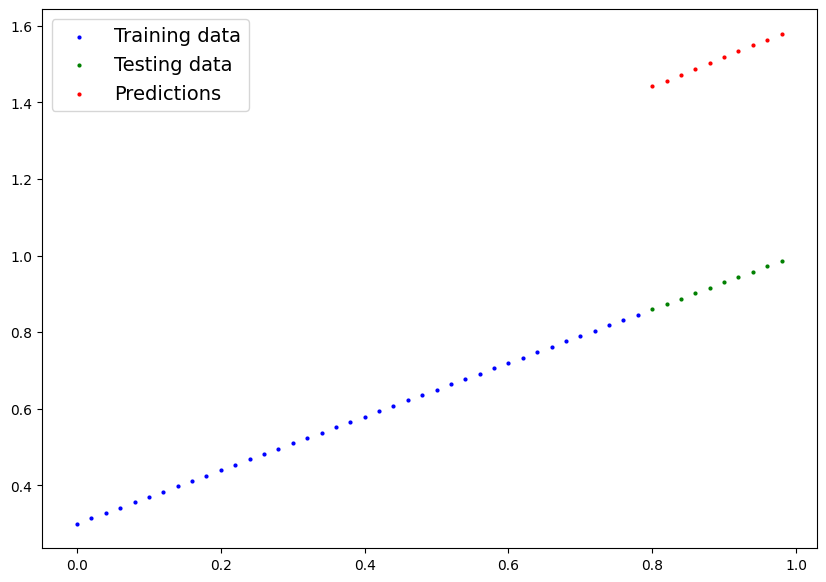

In [28]:
plot_predictions(predictions=y_preds)

Explanation:

Here, predictions are made without gradient descent. It is used for evaluation only,

Output:

Initial predictions are untrained and do not align well with the actual data distribution.

### Loss Function Selection

In [29]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [30]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1600

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.5551779866218567 | MAE Test Loss: 0.5739762187004089 
Epoch: 10 | MAE Train Loss: 0.4399680495262146 | MAE Test Loss: 0.4392663538455963 
Epoch: 20 | MAE Train Loss: 0.3247582018375397 | MAE Test Loss: 0.30455657839775085 
Epoch: 30 | MAE Train Loss: 0.20954827964305878 | MAE Test Loss: 0.16984674334526062 
Epoch: 40 | MAE Train Loss: 0.09433844685554504 | MAE Test Loss: 0.03513689711689949 
Epoch: 50 | MAE Train Loss: 0.023886386305093765 | MAE Test Loss: 0.04784906655550003 
Epoch: 60 | MAE Train Loss: 0.0199567973613739 | MAE Test Loss: 0.04580312222242355 
Epoch: 70 | MAE Train Loss: 0.016517987474799156 | MAE Test Loss: 0.0375305712223053 
Epoch: 80 | MAE Train Loss: 0.013089170679450035 | MAE Test Loss: 0.029944902285933495 
Epoch: 90 | MAE Train Loss: 0.009653178043663502 | MAE Test Loss: 0.02167237363755703 
Epoch: 100 | MAE Train Loss: 0.006215679459273815 | MAE Test Loss: 0.014086711220443249 
Epoch: 110 | MAE Train Loss: 0.002787243574857712 | MA

Output:

Model gradually learns the linear relationship between input and output variables by adjusting slope and intercept.

### Loss Curve Visualization

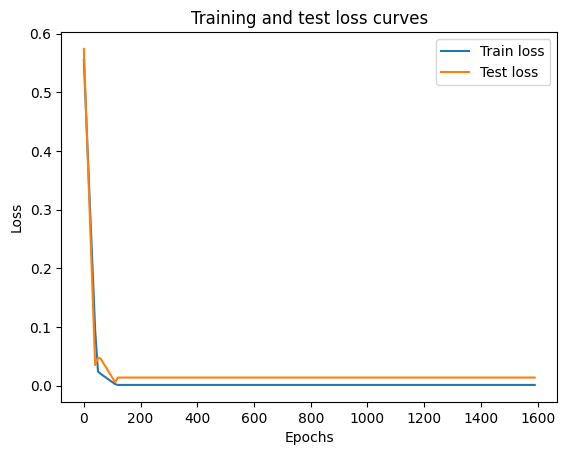

In [31]:

# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

The curves shows training vs testing error which help to verify machine learning.

Output:

The decreasing curve shows that the model is learning.


### Final Prediction Visualization

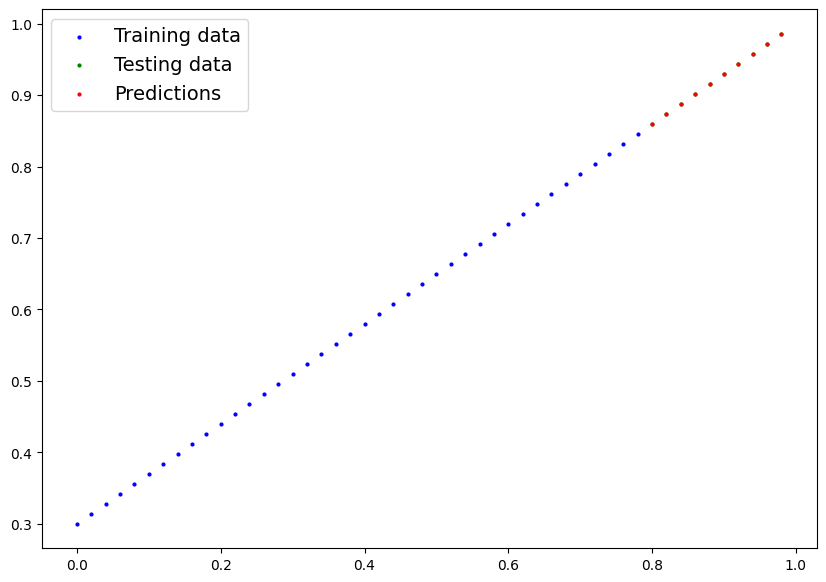

In [32]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

The Red points (predictions) align closely with actual data. Indicates successful learning of the linear relationship between variables.

## TASK 3: {DATASET = assignment-data2.csv}

### Data Preparation

In [33]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [34]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


Shape of X and y confirms correct tensor conversion

### Train-Test Split

In [35]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

Confirmed that the dataset is properly splitted into training and testing sets.

### Data Visualization Function

In [36]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

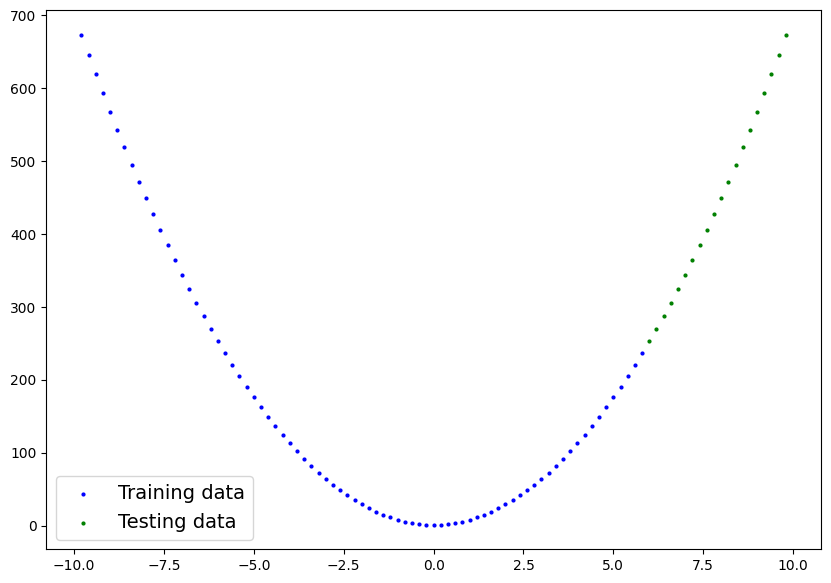

In [37]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function plots training data (blue), test data (green).

Output: Scatter plot showing dataset distribution helps visually understand pattern (quadratic curve)

### Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation: These are learnable parameters

Initialized randomly

Updated during training using gradient descent

In [38]:
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [39]:
model_0 = LinearRegressionNN()

In [40]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289]])

Explanation:

Here, the predictions are made without gradient tracking. It is used for only evaluation purpose.

Output:

Predictions are inaccurate initially.

In [41]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289],
        [6.1818],
        [6.3347],
        [6.4876],
        [6.6405],
        [6.7934],
        [6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579],
        [7.7109],
        [7.8638],
        [8.0167],
        [8.1696],
        [8.3225]])


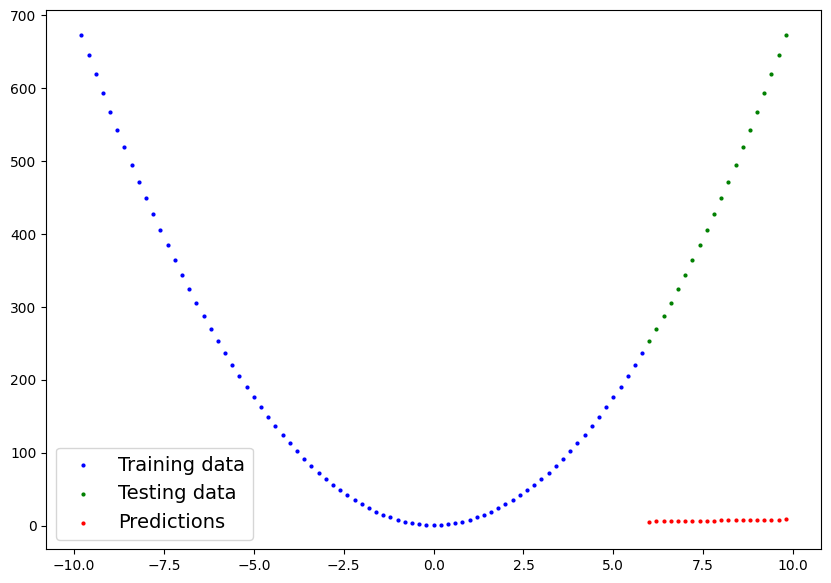

In [42]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [43]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [44]:

torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 175.299072265625 | MAE Test Loss: 440.4580993652344 
Epoch: 10 | MAE Train Loss: 174.799072265625 | MAE Test Loss: 441.9381408691406 
Epoch: 20 | MAE Train Loss: 174.30055236816406 | MAE Test Loss: 443.419189453125 
Epoch: 30 | MAE Train Loss: 173.80557250976562 | MAE Test Loss: 444.90167236328125 
Epoch: 40 | MAE Train Loss: 173.31057739257812 | MAE Test Loss: 446.3841857910156 
Epoch: 50 | MAE Train Loss: 172.8198699951172 | MAE Test Loss: 447.86572265625 
Epoch: 60 | MAE Train Loss: 172.3340301513672 | MAE Test Loss: 449.3526306152344 
Epoch: 70 | MAE Train Loss: 171.84864807128906 | MAE Test Loss: 450.84027099609375 
Epoch: 80 | MAE Train Loss: 171.36325073242188 | MAE Test Loss: 452.32781982421875 
Epoch: 90 | MAE Train Loss: 170.8778839111328 | MAE Test Loss: 453.8154296875 
Epoch: 100 | MAE Train Loss: 170.4003143310547 | MAE Test Loss: 455.29754638671875 
Epoch: 110 | MAE Train Loss: 169.923583984375 | MAE Test Loss: 456.77972412109375 
Epoch: 120 | M

Output:

- Loss decreases over time.

- Model gradually learns correct curve


### Loss Curve Visualization

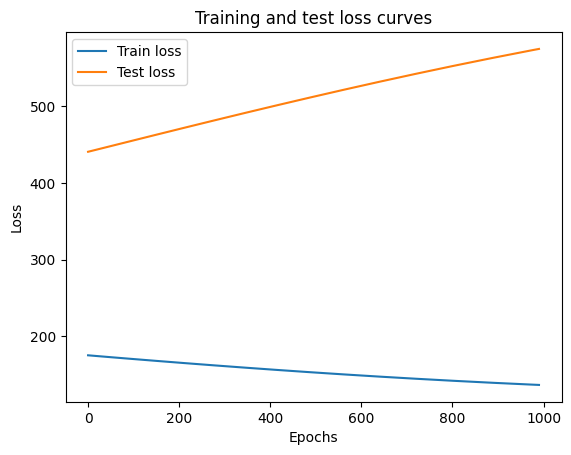

In [45]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

The curves shows training vs testing error which help to verify machine learning.

Output:

The decreasing curve shows that the model is learning.


### Final Prediction Visualization

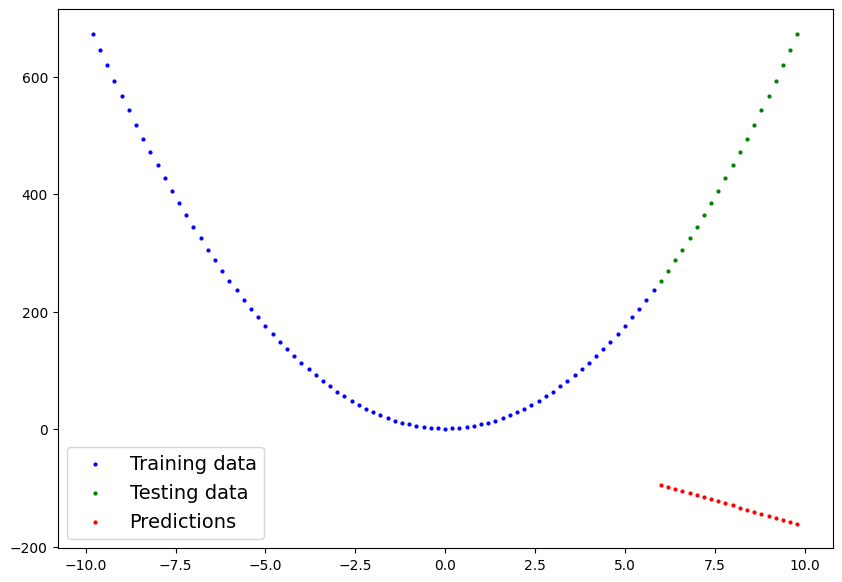

In [46]:

# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

--> The Red points (predictions) align closely with actual data Indicates successful learning of quadratic relationship

### TASK 1 DISCUSSION

The simple linear regression model (LinearRegressionNN) can be technically trained (meaning it can run backpropagation and update weights) on any dataset.

BUT the model/architecture is only appropriate for simple linear datasets (such as standard linear regression problems where the relationship between inputs and outputs follows a straight line). It is highly inappropriate for non-linear structures.



## TASK 2:



# Neural Network


<!-- ![Neural Network](https://miro.medium.com/0*lDbXVQhmjtlHjzKC.png) -->

### Data Retreival and Collection



In [47]:
import pandas as pd

path = r'binary_classification_moons.csv'

data = pd.read_csv(path)
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


### Data Cleaning 

In [48]:
data.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


Here, the data is clean, so no additional preprocessing steps are required.



### Feature Design

In NN, feature desisn is an automatic step. 

### Algorithm Selection

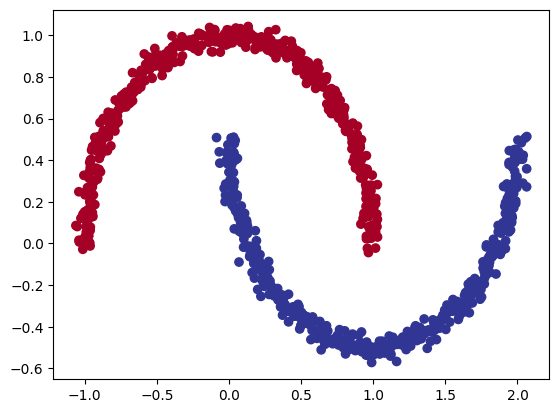

In [49]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=data.X1, 
            y=data.X2, 
            c=data.label, 
            cmap=plt.cm.RdYlBu
            );

In [50]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [51]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [52]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [53]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21672\3536051194.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [54]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [55]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [56]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)
    
    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [57]:
model = model_0

In [58]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1435],
        [-0.0799],
        [-0.1176],
        [-0.0775],
        [-0.0713],
        [-0.0593],
        [-0.0908],
        [-0.0988],
        [-0.1263],
        [-0.0826]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### Loss Function Selection

In [59]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

In [60]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.1435],
        [-0.0799],
        [-0.1176],
        [-0.0775],
        [-0.0713]], grad_fn=<SliceBackward0>)

In [61]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4642],
        [0.4800],
        [0.4706],
        [0.4806],
        [0.4822]], grad_fn=<SigmoidBackward0>)

In [62]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

In [63]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Model Learning

In [64]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device) 


### Model Evaluation

In [65]:
from utils import train_and_test_loop

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

Epoch: 0 | Loss: 0.69395, Accuracy: 50.00% | Test loss: 0.68147, Test acc: 58.50%
Epoch: 10 | Loss: 0.57149, Accuracy: 79.12% | Test loss: 0.57350, Test acc: 75.00%
Epoch: 20 | Loss: 0.48652, Accuracy: 81.12% | Test loss: 0.49746, Test acc: 79.00%
Epoch: 30 | Loss: 0.42603, Accuracy: 82.00% | Test loss: 0.44278, Test acc: 80.50%
Epoch: 40 | Loss: 0.38463, Accuracy: 82.25% | Test loss: 0.40451, Test acc: 81.00%
Epoch: 50 | Loss: 0.35657, Accuracy: 82.88% | Test loss: 0.37765, Test acc: 81.50%
Epoch: 60 | Loss: 0.33707, Accuracy: 83.12% | Test loss: 0.35814, Test acc: 81.50%
Epoch: 70 | Loss: 0.32288, Accuracy: 83.75% | Test loss: 0.34328, Test acc: 81.50%
Epoch: 80 | Loss: 0.31201, Accuracy: 84.00% | Test loss: 0.33141, Test acc: 82.00%
Epoch: 90 | Loss: 0.30329, Accuracy: 84.75% | Test loss: 0.32152, Test acc: 83.00%


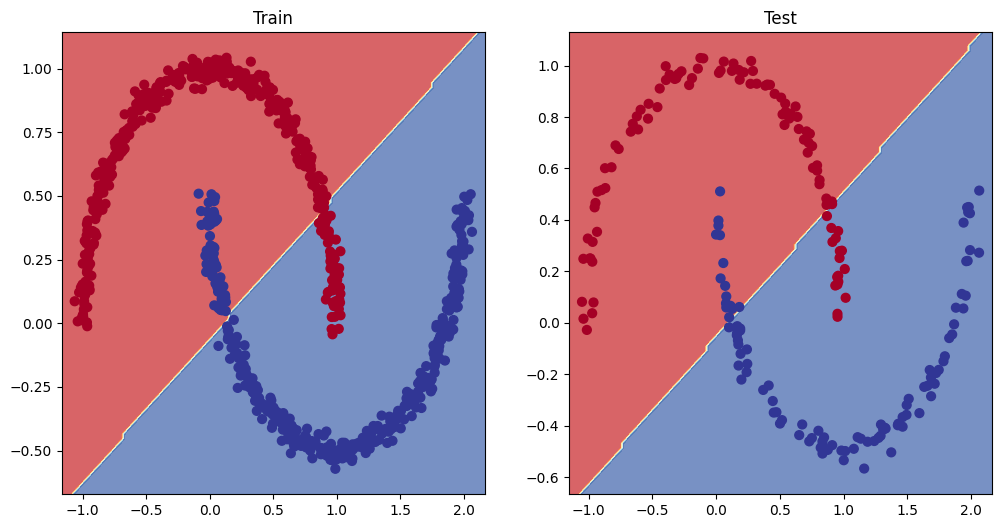

In [66]:
from utils import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In machine learning terms, our model is `underfitting`, meaning it's not learning predictive patterns from the data.

Let's also plot the loss graph: 


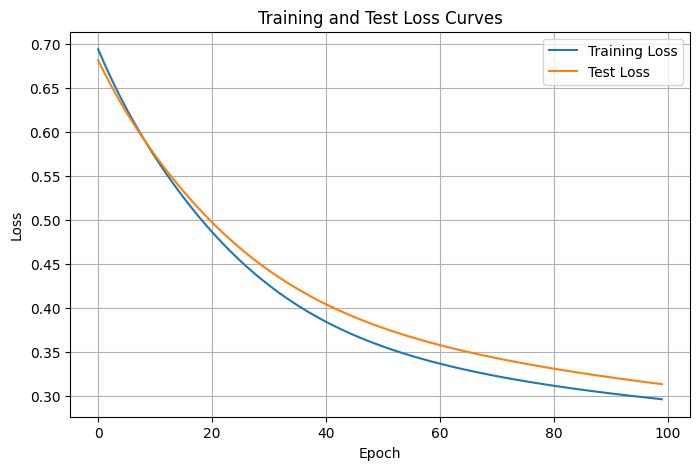

In [67]:

import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

In [68]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [69]:
model = model_1
epochs = 1000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.70134, Test acc: 45.50%
Epoch: 10 | Loss: 0.58674, Accuracy: 79.62% | Test loss: 0.58552, Test acc: 78.00%
Epoch: 20 | Loss: 0.47594, Accuracy: 79.62% | Test loss: 0.48700, Test acc: 77.00%
Epoch: 30 | Loss: 0.39832, Accuracy: 81.00% | Test loss: 0.41841, Test acc: 77.00%
Epoch: 40 | Loss: 0.35499, Accuracy: 81.62% | Test loss: 0.37773, Test acc: 78.00%
Epoch: 50 | Loss: 0.32886, Accuracy: 82.62% | Test loss: 0.35055, Test acc: 80.50%
Epoch: 60 | Loss: 0.31010, Accuracy: 83.75% | Test loss: 0.32940, Test acc: 82.00%
Epoch: 70 | Loss: 0.29513, Accuracy: 84.75% | Test loss: 0.31171, Test acc: 83.50%
Epoch: 80 | Loss: 0.28276, Accuracy: 85.00% | Test loss: 0.29670, Test acc: 85.50%
Epoch: 90 | Loss: 0.27260, Accuracy: 85.62% | Test loss: 0.28413, Test acc: 86.50%
Epoch: 100 | Loss: 0.26443, Accuracy: 86.25% | Test loss: 0.27384, Test acc: 87.50%
Epoch: 110 | Loss: 0.25803, Accuracy: 87.00% | Test loss: 0.26561, Test acc: 87.50%
Epo

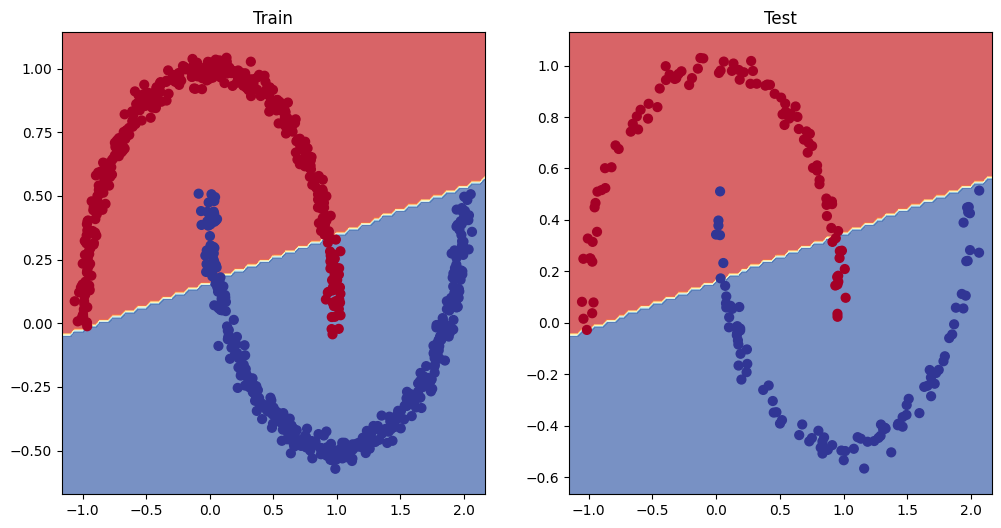

In [70]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

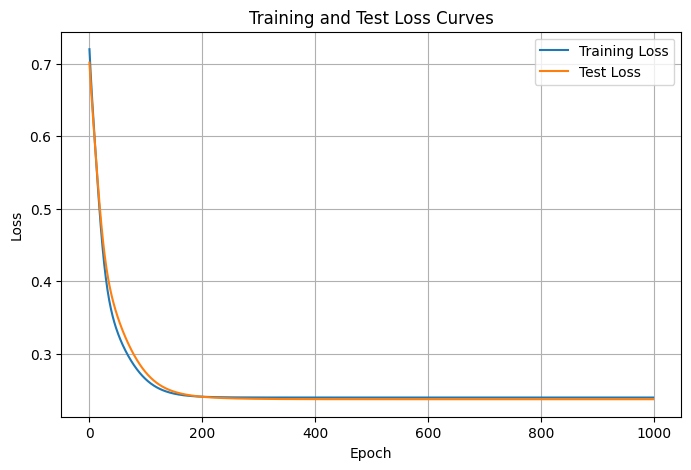

In [71]:
plot_loss_curves(train_losses, test_losses)

In [72]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    plt.figure(figsize=(10, 7))

    # Training data
    plt.scatter(train_data[:, 0],
                train_data[:, 1],
                c=train_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Train")

    # Test data
    plt.scatter(test_data[:, 0],
                test_data[:, 1],
                c=test_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Test")

    if predictions is not None:
        plt.scatter(test_data[:, 0],
                    test_data[:, 1],
                    c=predictions.detach().numpy(),
                    cmap=plt.cm.RdYlBu,
                    marker="x",
                    s=80,
                    label="Predictions")

    plt.legend()
    plt.show()

In [73]:
y_preds = model_0(X_test)
y_preds = torch.round(torch.sigmoid(y_preds))

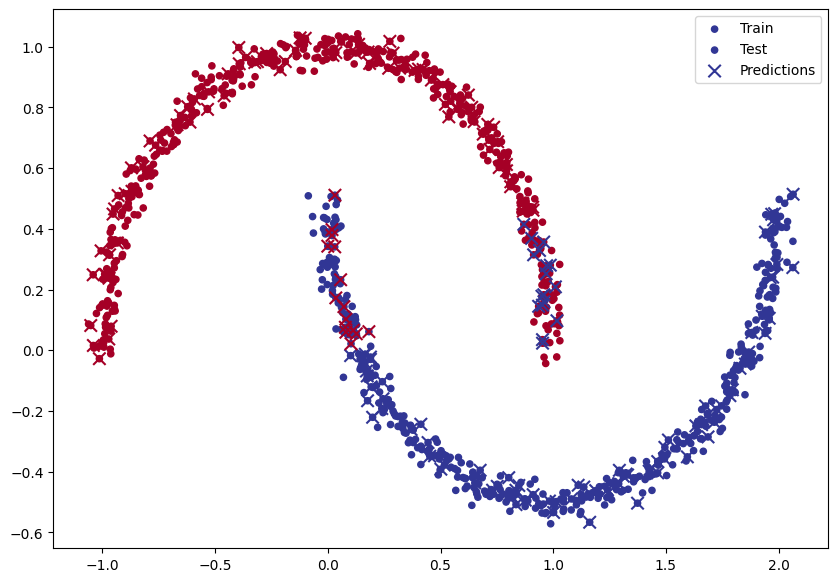

In [74]:
plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=y_preds
    
)

## using linear model

<!-- ![Neural Network](https://miro.medium.com/0*lDbXVQhmjtlHjzKC.png) -->

In [75]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [76]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### 1. Data Preparation

In [77]:
import pandas as pd
import torch

df = pd.read_csv(r'binary_classification_moons.csv')
df.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [78]:
X = torch.tensor(
    df[['X1', 'X2']].values,
    dtype=torch.float32
)

y = torch.tensor(
    df['label'].values.reshape(-1, 1),
    dtype=torch.float32
)

print(X.shape)
print(y.shape)

torch.Size([1000, 2])
torch.Size([1000, 1])


Here, Shape of X1 and X2 confirms correct tensor conversion

### Train-Test Split

In [79]:

train_split = int(0.8 * len(X))

X_train = X[:train_split]
y_train = y[:train_split]

X_test = X[train_split:]
y_test = y[train_split:]

print(len(X_train))
print(len(X_test))

800
200


### Data Visualization Function

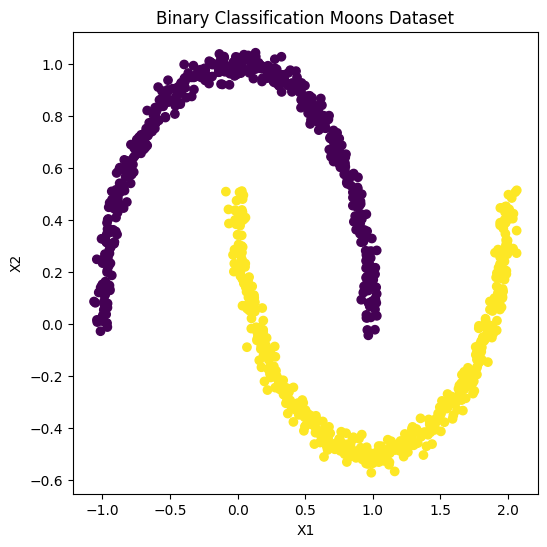

In [80]:
plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y.squeeze(),
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Binary Classification Moons Dataset")
plt.show()

### Algorithm Selection

We define a linear regression model: y = wx + b

This model is suitable because the dataset shows a straight-line relationship between input and output variables.

In [81]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=2,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [82]:
model_0 = LinearRegressionNN()



In [83]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[-0.5621],
        [-1.1373],
        [-0.5582],
        [-0.8890],
        [-0.8237]])

In [84]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 200
Number of predictions made: 200
Predicted values:
tensor([[-0.5621],
        [-1.1373],
        [-0.5582],
        [-0.8890],
        [-0.8237],
        [-0.6255],
        [-0.6915],
        [-0.7603],
        [-0.5561],
        [-0.8387],
        [-0.5645],
        [-0.7588],
        [-0.6309],
        [-1.0537],
        [-1.0072],
        [-0.9852],
        [-1.1243],
        [-0.7574],
        [-0.8258],
        [-0.5653],
        [-0.6264],
        [-0.7767],
        [-0.5588],
        [-0.7042],
        [-0.2524],
        [-0.5630],
        [-1.0603],
        [-0.6889],
        [-0.3310],
        [-0.8877],
        [-0.3287],
        [-0.8253],
        [-0.9794],
        [-0.6564],
        [-0.8193],
        [-0.8331],
        [-0.6235],
        [-1.1237],
        [-0.5904],
        [-0.7826],
        [-0.5507],
        [-0.7350],
        [-0.6792],
        [-0.8127],
        [-0.9126],
        [-0.7474],
        [-0.5716],
        [-0.3305],
       

### Loss Function Selection

In [85]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [86]:
epochs = 1000

for epoch in range(epochs):

    # Training
    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # Testing
    model_0.eval()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_fn(
            test_pred,
            y_test
        )

        pred_labels = (
            test_pred >= 0.5
        ).float()

        accuracy = (
            pred_labels == y_test
        ).float().mean()

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Train Loss: {loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

Epoch: 0 | Train Loss: 1.2043 | Test Loss: 1.1722 | Accuracy: 0.5050
Epoch: 100 | Train Loss: 0.4179 | Test Loss: 0.4160 | Accuracy: 0.5050
Epoch: 200 | Train Loss: 0.2349 | Test Loss: 0.2457 | Accuracy: 0.7800
Epoch: 300 | Train Loss: 0.2104 | Test Loss: 0.2231 | Accuracy: 0.8000
Epoch: 400 | Train Loss: 0.2044 | Test Loss: 0.2164 | Accuracy: 0.8150
Epoch: 500 | Train Loss: 0.2025 | Test Loss: 0.2151 | Accuracy: 0.8200
Epoch: 600 | Train Loss: 0.2018 | Test Loss: 0.2149 | Accuracy: 0.8350
Epoch: 700 | Train Loss: 0.2016 | Test Loss: 0.2146 | Accuracy: 0.8500
Epoch: 800 | Train Loss: 0.2015 | Test Loss: 0.2145 | Accuracy: 0.8500
Epoch: 900 | Train Loss: 0.2014 | Test Loss: 0.2145 | Accuracy: 0.8550


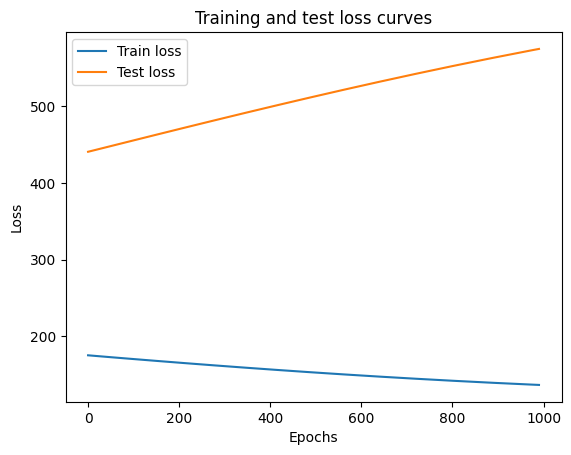

In [87]:

# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

### Evaluation

In [88]:
model_0.eval()

with torch.inference_mode():

    y_probs = model_0(X_test)

    y_preds = (
        y_probs >= 0.5
    ).float()

accuracy = (
    y_preds == y_test
).float().mean()

print(
    f"Final Test Accuracy: {accuracy:.4f}"
)

Final Test Accuracy: 0.8550


### Final Prediction Visualization

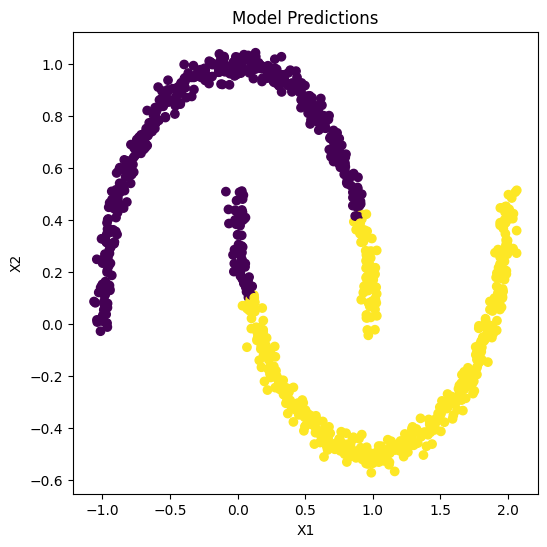

In [89]:
model_0.eval()

with torch.inference_mode():

    all_probs = model_0(X)

    all_preds = (
        all_probs >= 0.5
    ).float()

plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=all_preds.squeeze(),
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Model Predictions")
plt.show()

### TASK 2 DISCUSSION

1. Is the LinearRegressionNN model suitable?

--> No, it is not suitable.

2. Is the ModelV0 model suitable?

--> No, it is also not suitable.
Although ModelV0 is built with multiple hidden layers, it is entirely constructed of linear transformations stacked on top of each other without any non-linear activation functions interspaced between them.

3. Modify the model by increasing the number of layers and/or hidden units. An example is provided in Lab-5.1-NN.ipynb. Evaluate the suitability of the resulting model architecture(s) for the binary_classification_moons.csv dataset and justify your conclusions.

-->The network was scaled up to include multiple hidden layers with an increased number of hidden units.
so, this modified model architecture is highly suitable for the binary_classification_moons.csv dataset.

## TASK 3

In [90]:
import pandas as pd

path = r'binary_classification_moons.csv'

data = pd.read_csv(path)
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [91]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [92]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [93]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [94]:
# Build model with non-linear activation function
from torch import nn
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = ModelV2().to(device)
print(model_2)

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [95]:
from utils import train_and_test_loop, plot_decision_boundary
import matplotlib.pyplot as plt

Epoch: 0 | Loss: 0.70685, Accuracy: 50.00% | Test loss: 0.70478, Test acc: 50.00%
Epoch: 10 | Loss: 0.69329, Accuracy: 50.00% | Test loss: 0.69241, Test acc: 50.00%
Epoch: 20 | Loss: 0.68207, Accuracy: 50.00% | Test loss: 0.68188, Test acc: 50.00%


Epoch: 30 | Loss: 0.66832, Accuracy: 72.75% | Test loss: 0.66868, Test acc: 78.50%
Epoch: 40 | Loss: 0.64834, Accuracy: 83.75% | Test loss: 0.64958, Test acc: 84.00%
Epoch: 50 | Loss: 0.62031, Accuracy: 83.50% | Test loss: 0.62307, Test acc: 81.00%
Epoch: 60 | Loss: 0.58432, Accuracy: 82.75% | Test loss: 0.58972, Test acc: 79.00%
Epoch: 70 | Loss: 0.54354, Accuracy: 82.50% | Test loss: 0.55235, Test acc: 79.50%
Epoch: 80 | Loss: 0.50252, Accuracy: 83.12% | Test loss: 0.51477, Test acc: 80.50%
Epoch: 90 | Loss: 0.46389, Accuracy: 83.00% | Test loss: 0.47871, Test acc: 82.00%


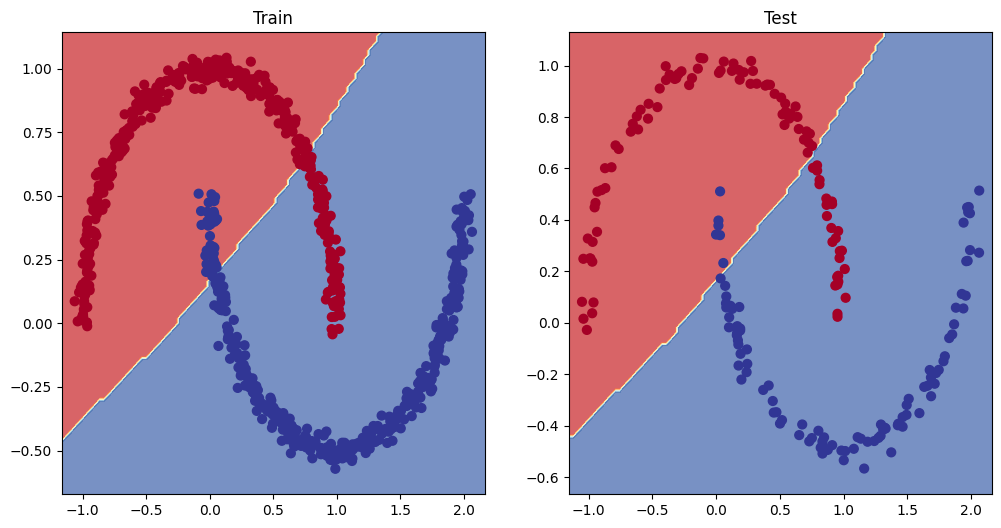

In [96]:
model = model_2
epochs = 100

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

training more epochs to see if we can get better results

Epoch: 0 | Loss: 0.70305, Accuracy: 50.62% | Test loss: 0.70282, Test acc: 52.50%
Epoch: 10 | Loss: 0.68405, Accuracy: 62.00% | Test loss: 0.68438, Test acc: 60.00%
Epoch: 20 | Loss: 0.66341, Accuracy: 77.12% | Test loss: 0.66388, Test acc: 74.50%
Epoch: 30 | Loss: 0.64187, Accuracy: 82.00% | Test loss: 0.64217, Test acc: 82.00%
Epoch: 40 | Loss: 0.61670, Accuracy: 83.38% | Test loss: 0.61706, Test acc: 82.50%
Epoch: 50 | Loss: 0.58466, Accuracy: 84.50% | Test loss: 0.58550, Test acc: 83.50%
Epoch: 60 | Loss: 0.54467, Accuracy: 84.62% | Test loss: 0.54670, Test acc: 80.50%
Epoch: 70 | Loss: 0.49761, Accuracy: 84.88% | Test loss: 0.50121, Test acc: 81.00%
Epoch: 80 | Loss: 0.44649, Accuracy: 85.25% | Test loss: 0.45214, Test acc: 82.00%
Epoch: 90 | Loss: 0.39751, Accuracy: 85.75% | Test loss: 0.40525, Test acc: 82.00%
Epoch: 100 | Loss: 0.35634, Accuracy: 86.00% | Test loss: 0.36545, Test acc: 83.50%
Epoch: 110 | Loss: 0.32476, Accuracy: 86.50% | Test loss: 0.33400, Test acc: 85.00%
Epo

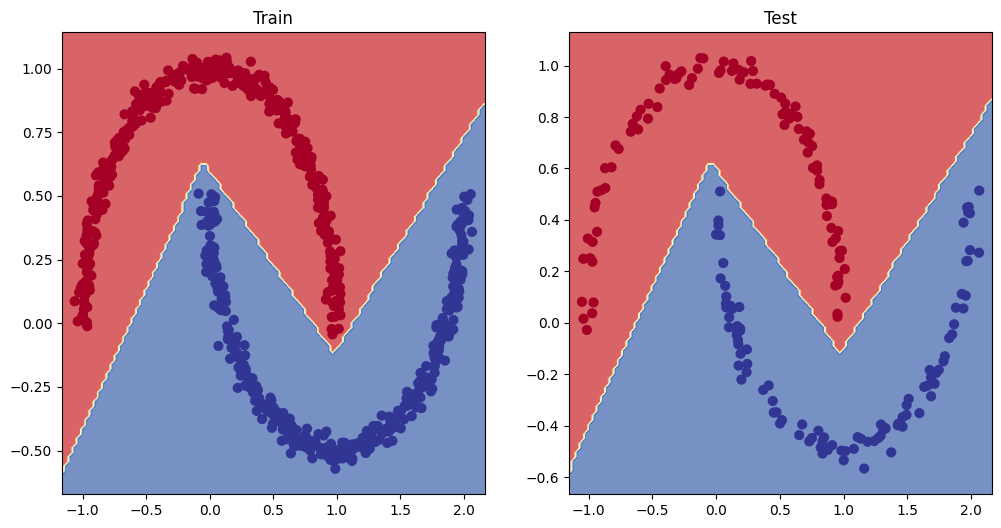

In [97]:
epochs = 1000
model = ModelV2().to(device) # reset model
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

**This is the reason why Activation Function is necessary:**
![Neuron](https://towardsdatascience.com/wp-content/uploads/2021/12/1hkYlTODpjJgo32DoCOWN5w.png)

Epoch: 0 | Loss: 0.71349, Accuracy: 50.00% | Test loss: 0.70825, Test acc: 50.00%
Epoch: 10 | Loss: 0.69375, Accuracy: 50.00% | Test loss: 0.69095, Test acc: 50.00%
Epoch: 20 | Loss: 0.67903, Accuracy: 62.50% | Test loss: 0.67755, Test acc: 68.00%
Epoch: 30 | Loss: 0.66454, Accuracy: 85.50% | Test loss: 0.66384, Test acc: 86.50%
Epoch: 40 | Loss: 0.64602, Accuracy: 84.88% | Test loss: 0.64605, Test acc: 84.50%
Epoch: 50 | Loss: 0.62024, Accuracy: 85.12% | Test loss: 0.62154, Test acc: 83.50%
Epoch: 60 | Loss: 0.58498, Accuracy: 84.88% | Test loss: 0.58823, Test acc: 83.00%
Epoch: 70 | Loss: 0.54130, Accuracy: 84.00% | Test loss: 0.54768, Test acc: 83.50%
Epoch: 80 | Loss: 0.49811, Accuracy: 83.88% | Test loss: 0.50724, Test acc: 84.50%
Epoch: 90 | Loss: 0.45657, Accuracy: 84.12% | Test loss: 0.46747, Test acc: 84.00%
Epoch: 100 | Loss: 0.41749, Accuracy: 84.75% | Test loss: 0.42876, Test acc: 85.00%
Epoch: 110 | Loss: 0.38156, Accuracy: 85.25% | Test loss: 0.39211, Test acc: 86.00%
Epo

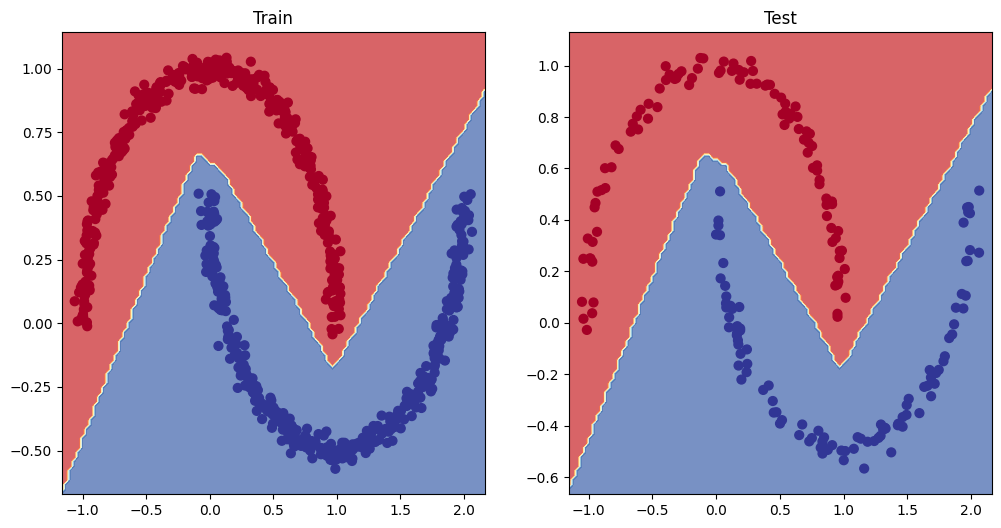

In [98]:
model = ModelV2().to(device) # reset model
epochs = 1500
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

### predictions

In [99]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    plt.figure(figsize=(10, 7))

    # Training data
    plt.scatter(train_data[:, 0],
                train_data[:, 1],
                c=train_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Train")

    # Test data
    plt.scatter(test_data[:, 0],
                test_data[:, 1],
                c=test_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Test")

    if predictions is not None:
        plt.scatter(test_data[:, 0],
                    test_data[:, 1],
                    c=predictions.detach().numpy(),
                    cmap=plt.cm.RdYlBu,
                    marker="x",
                    s=80,
                    label="Predictions")

    plt.legend()
    plt.show()

In [100]:
y_preds = model(X_test)
y_preds = torch.round(torch.sigmoid(y_preds))

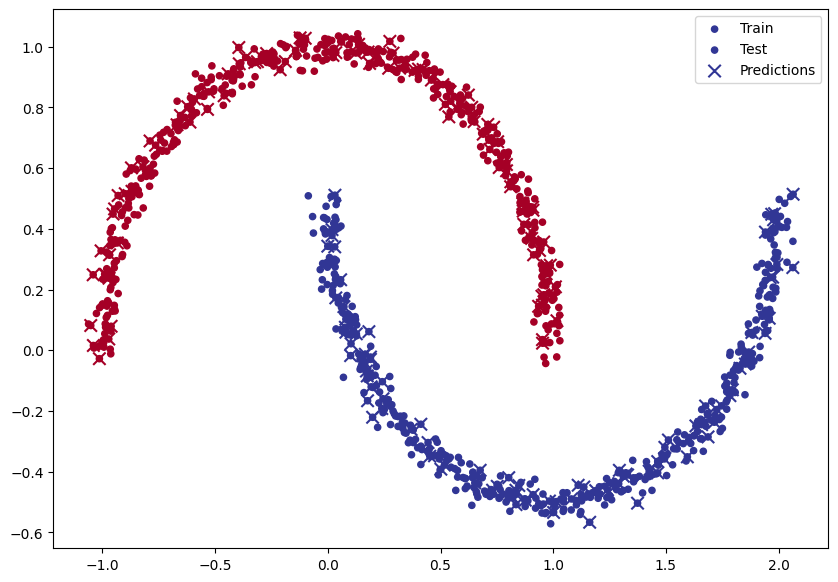

In [101]:
plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=y_preds
    
)

### TASK 3 DISCUSSION

Without an activation function, stacking millions of hidden layers still yields a simple linear model. Activation functions apply non-linear mathematical operations (like ReLU, Sigmoid, or Tanh) element-wise to the outputs of linear layers. This breaks the linear collapse, allowing the network to model highly curved decision boundaries